In [1]:
import numpy as np
import pandas as pd
df=pd.read_csv("feedback_sentiment.csv")

In [2]:
df.head()

,"Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score"
0,"""I love this product!"", Positive, Twitter, 202..."
1,"""The service was terrible."", Negative, Yelp Re..."
2,"""This movie is amazing!"", Positive, IMDb, 2023..."
3,"""I'm so disappointed with their customer suppo..."
4,"""Just had the best meal of my life!"", Positive..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 1 columns):
 #   Column                                                                   Non-Null Count  Dtype 
---  ------                                                                   --------------  ----- 
 0   Text, Sentiment, Source, Date/Time, User ID, Location, Confidence Score  96 non-null     object
dtypes: object(1)
memory usage: 916.0+ bytes


In [4]:
# 進行拆分
df.columns = ['raw_data']
df[['text', 'sentiment', 'source', 'date/time', 'user_id', 'location', 'confidence_score']] = df['raw_data'].str.split(',', expand=True)
# 刪除原始欄位
df.drop(columns=['raw_data'], inplace=True)

Q1. How many columns are there in this csv file and what are these columns’ names?

In [6]:
df.head(10)

,text,sentiment,source,date/time,user_id,location,confidence_score
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88
5,"""The quality of this product is subpar.""",Negative,Amazon Reviews,2023-06-16 10:15:27,shopper123,San Francisco,0.72
6,"""I can't stop listening to this song. It's inc...",Positive,Spotify,2023-06-16 13:40:18,musiclover456,Berlin,0.91
7,"""Their website is so user-friendly. Love it!""",Positive,Website Testimonial,2023-06-16 16:05:36,testimonialuser1,Sydney,0.87
8,"""I loved the movie! It was fantastic!""",Positive,IMDb,2023-07-02 09:12:34,user123,New York,0.92
9,"""The customer service was terrible.""",Negative,Yelp Reviews,2023-07-02 10:45:21,user456,Los Angeles,0.65


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   text              96 non-null     object
 1   sentiment         96 non-null     object
 2   source            96 non-null     object
 3   date/time         96 non-null     object
 4   user_id           96 non-null     object
 5   location          96 non-null     object
 6   confidence_score  96 non-null     object
dtypes: object(7)
memory usage: 5.5+ KB


Q2. Do the following steps and show the corresponding results. 
●	Clean data
●	Drop nan
●	Convert data and time to datatime
●	Create new features - month, day, and hour
●	Create new features again - Total Words, Total Chars, and Total Words After Transformation of "Text," where Total Words After Transformation means The natural logarithm of the word count of the "Text".


clean data

In [10]:
#缺失值
df.isnull().sum()

text                2
sentiment           2
source              2
date/time           2
user_id             2
location            2
confidence_score    2
dtype: int64

In [11]:
df = df.dropna(axis=0, how='any')
df.isnull().sum()

text                0
sentiment           0
source              0
date/time           0
user_id             0
location            0
confidence_score    0
dtype: int64

In [12]:
df.head(10)

,text,sentiment,source,date/time,user_id,location,confidence_score
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88
5,"""The quality of this product is subpar.""",Negative,Amazon Reviews,2023-06-16 10:15:27,shopper123,San Francisco,0.72
6,"""I can't stop listening to this song. It's inc...",Positive,Spotify,2023-06-16 13:40:18,musiclover456,Berlin,0.91
7,"""Their website is so user-friendly. Love it!""",Positive,Website Testimonial,2023-06-16 16:05:36,testimonialuser1,Sydney,0.87
8,"""I loved the movie! It was fantastic!""",Positive,IMDb,2023-07-02 09:12:34,user123,New York,0.92
9,"""The customer service was terrible.""",Negative,Yelp Reviews,2023-07-02 10:45:21,user456,Los Angeles,0.65


In [13]:
#重複值
df.duplicated().sum()

21

In [14]:
df = df.drop_duplicates()
df.head(10)

,text,sentiment,source,date/time,user_id,location,confidence_score
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88
5,"""The quality of this product is subpar.""",Negative,Amazon Reviews,2023-06-16 10:15:27,shopper123,San Francisco,0.72
6,"""I can't stop listening to this song. It's inc...",Positive,Spotify,2023-06-16 13:40:18,musiclover456,Berlin,0.91
7,"""Their website is so user-friendly. Love it!""",Positive,Website Testimonial,2023-06-16 16:05:36,testimonialuser1,Sydney,0.87
8,"""I loved the movie! It was fantastic!""",Positive,IMDb,2023-07-02 09:12:34,user123,New York,0.92
9,"""The customer service was terrible.""",Negative,Yelp Reviews,2023-07-02 10:45:21,user456,Los Angeles,0.65


Convert data and time to datatime

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 0 to 74
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   text              75 non-null     object
 1   sentiment         75 non-null     object
 2   source            75 non-null     object
 3   date/time         75 non-null     object
 4   user_id           75 non-null     object
 5   location          75 non-null     object
 6   confidence_score  75 non-null     object
dtypes: object(7)
memory usage: 4.7+ KB


In [17]:
#將時間調整成python可讀的形式
df['date/time']=pd.to_datetime(df['date/time'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 0 to 74
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   text              75 non-null     object        
 1   sentiment         75 non-null     object        
 2   source            75 non-null     object        
 3   date/time         75 non-null     datetime64[ns]
 4   user_id           75 non-null     object        
 5   location          75 non-null     object        
 6   confidence_score  75 non-null     object        
dtypes: datetime64[ns](1), object(6)
memory usage: 4.7+ KB


Create new features - month, day, and hour

In [19]:
df['month']=df['date/time'].dt.month
df['day']=df['date/time'].dt.day
df['hour']=df['date/time'].dt.hour
df.head()

,text,sentiment,source,date/time,user_id,location,confidence_score,month,day,hour
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,6,15,9
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,6,15,11
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,6,15,14
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,6,15,17
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,6,16,8


In [20]:
df['Total Words'] = df['text'].str.split().str.len()
df['Total Chars'] = df['text'].str.len()
df['Total Words After Transformation'] = np.log(df['Total Words'])
df.head(10)

,text,sentiment,source,date/time,user_id,location,confidence_score,month,day,hour,Total Words,Total Chars,Total Words After Transformation
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,6,15,9,4,22,1.386294
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,6,15,11,4,27,1.386294
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,6,15,14,4,24,1.386294
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,6,15,17,7,50,1.945910
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,6,16,8,8,36,2.079442
5,"""The quality of this product is subpar.""",Negative,Amazon Reviews,2023-06-16 10:15:27,shopper123,San Francisco,0.72,6,16,10,7,40,1.945910
6,"""I can't stop listening to this song. It's inc...",Positive,Spotify,2023-06-16 13:40:18,musiclover456,Berlin,0.91,6,16,13,9,55,2.197225
7,"""Their website is so user-friendly. Love it!""",Positive,Website Testimonial,2023-06-16 16:05:36,testimonialuser1,Sydney,0.87,6,16,16,7,45,1.945910
8,"""I loved the movie! It was fantastic!""",Positive,IMDb,2023-07-02 09:12:34,user123,New York,0.92,7,2,9,7,38,1.945910
9,"""The customer service was terrible.""",Negative,Yelp Reviews,2023-07-02 10:45:21,user456,Los Angeles,0.65,7,2,10,5,36,1.609438


 Q3. Do the following visualizations, eg., histplot, displot, barplot, kdeplot, etc., and write your findings.

1. by Sentiment 'Positive' and 'Negative'  (pie chart)

In [23]:
print(df['sentiment'].unique())

[' Positive' ' Negative']


In [24]:
df = df.dropna(subset=['sentiment'])
df['sentiment_code']=df['sentiment'].map({' Positive':1, ' Negative':0}).astype('int')
df['sentiment_code']

0     1
1     0
2     1
3     0
4     1
     ..
70    1
71    0
72    1
73    1
74    0
Name: sentiment_code, Length: 75, dtype: int32

In [25]:
Positive=(df['sentiment_code']==1).sum()
Negative=(df['sentiment_code']==0).sum()

<function matplotlib.pyplot.show(close=None, block=None)>

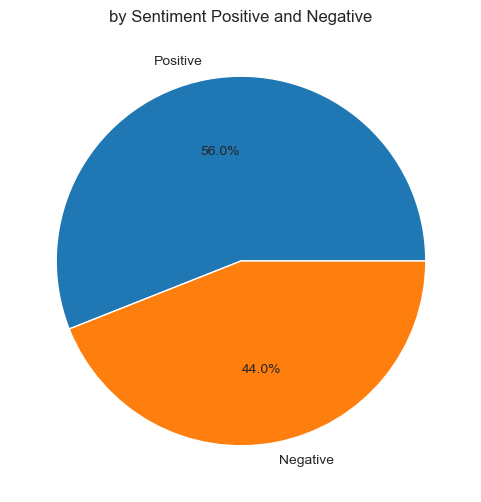

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt
data=[Positive,Negative]
labels=['Positive','Negative']
sns.set_style("whitegrid")
plt.figure(figsize=(6,6))
plt.pie(data, labels=labels, autopct='%1.1f%%')
plt.title('by Sentiment Positive and Negative')
plt.show

2. by 'Source' and 'Sentiment' (Horizontal bar plots)

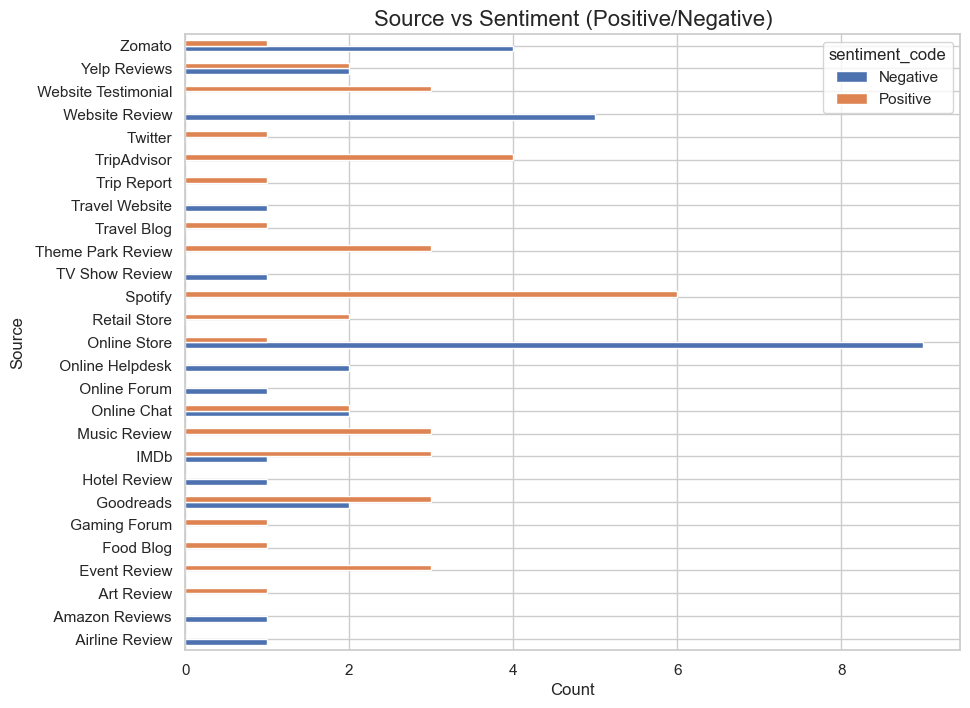

In [28]:
# 設置繪圖風格
sns.set(style="whitegrid")

# 使用 groupby 和 size 計算每個 source 中 sentiment 的分佈
source_sentiment_counts = df.groupby(['source', 'sentiment_code']).size().unstack(fill_value=0)

# 替換 sentiment_code 的 0 和 1 為 Negative 和 Positive
source_sentiment_counts.columns = source_sentiment_counts.columns.map({0: 'Negative', 1: 'Positive'})

# 繪製水平條形圖
ax = source_sentiment_counts.plot(kind='barh', stacked=False, figsize=(10, 8))

# 設置標題和標籤
ax.set_title('Source vs Sentiment (Positive/Negative)', fontsize=16)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Source', fontsize=12)

# 顯示圖表
plt.show()

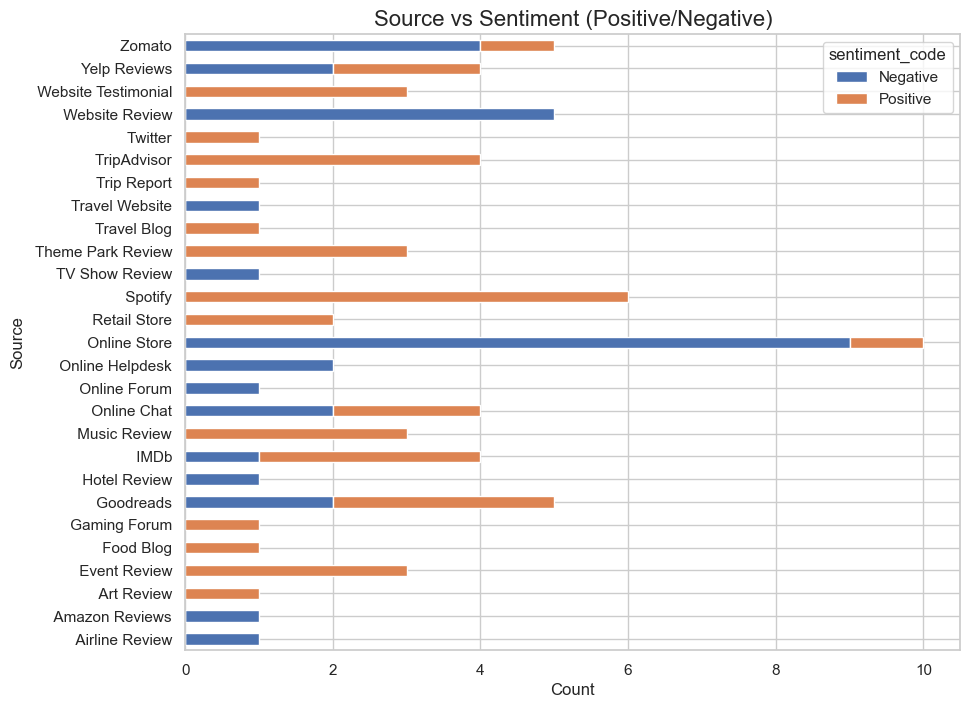

In [29]:
# 設置繪圖風格
sns.set(style="whitegrid")

# 使用 groupby 和 size 計算每個 source 中 sentiment 的分佈
source_sentiment_counts = df.groupby(['source', 'sentiment_code']).size().unstack(fill_value=0)

# 替換 sentiment_code 的 0 和 1 為 Negative 和 Positive
source_sentiment_counts.columns = source_sentiment_counts.columns.map({0: 'Negative', 1: 'Positive'})

# 繪製水平條形圖
ax = source_sentiment_counts.plot(kind='barh', stacked=True, figsize=(10, 8))

# 設置標題和標籤
ax.set_title('Source vs Sentiment (Positive/Negative)', fontsize=16)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Source', fontsize=12)

# 顯示圖表
plt.show()

3. by 'Location' and 'Sentiment'

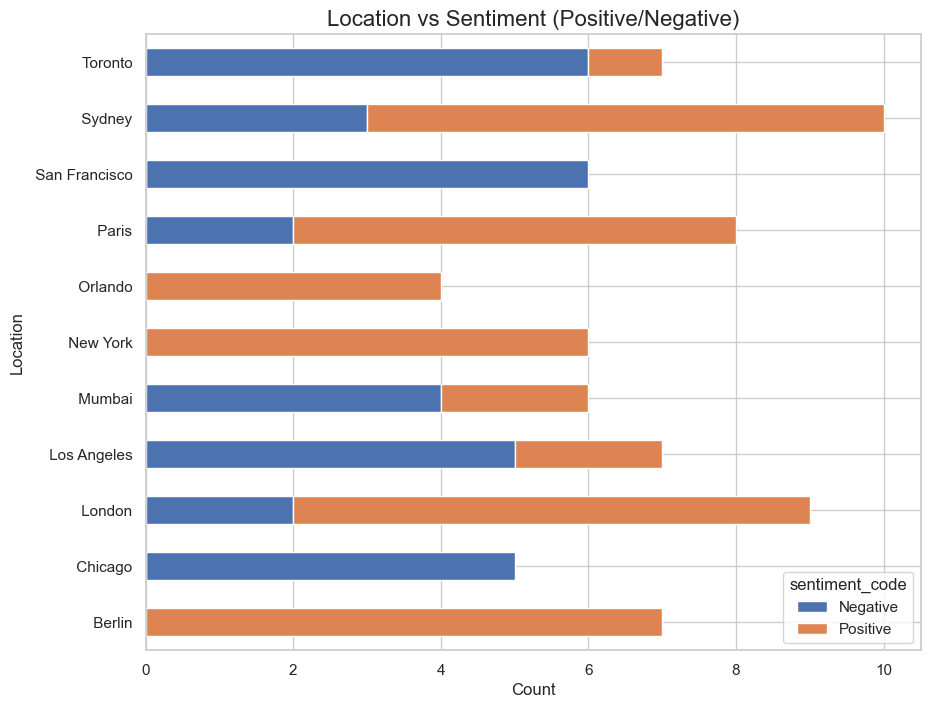

In [31]:
# 設置繪圖風格
sns.set(style="whitegrid")

# 使用 groupby 和 size 計算每個 source 中 sentiment 的分佈
source_sentiment_counts = df.groupby(['location', 'sentiment_code']).size().unstack(fill_value=0)

# 替換 sentiment_code 的 0 和 1 為 Negative 和 Positive
source_sentiment_counts.columns = source_sentiment_counts.columns.map({0: 'Negative', 1: 'Positive'})

# 繪製水平條形圖
ax = source_sentiment_counts.plot(kind='barh', stacked=True, figsize=(10, 8))

# 設置標題和標籤
ax.set_title('Location vs Sentiment (Positive/Negative)', fontsize=16)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Location', fontsize=12)

# 顯示圖表
plt.show()

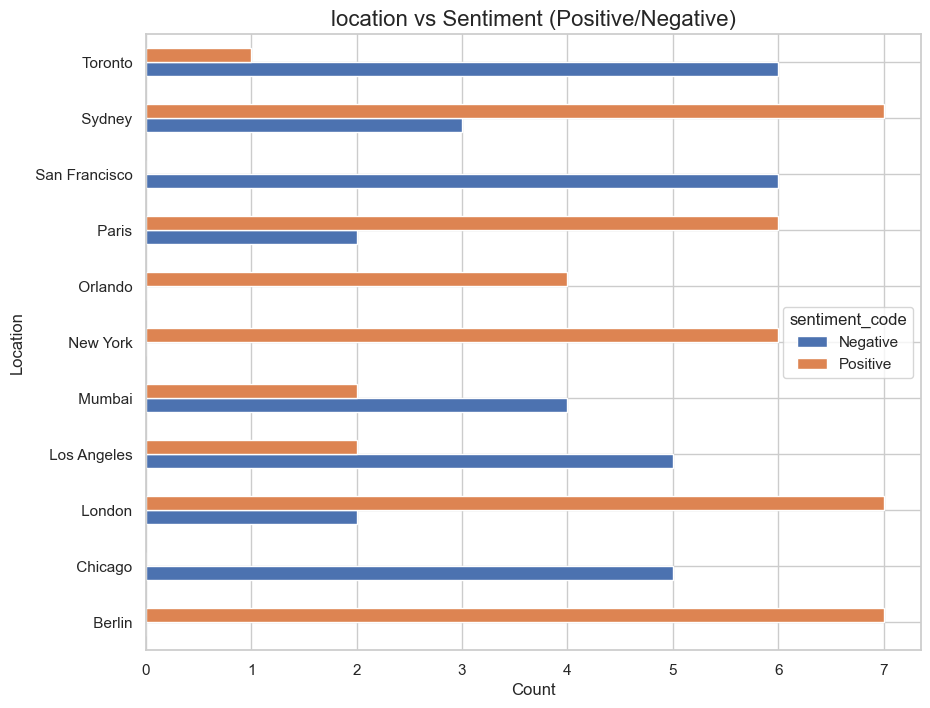

In [32]:
# 設置繪圖風格
sns.set(style="whitegrid")

# 使用 groupby 和 size 計算每個 source 中 sentiment 的分佈
source_sentiment_counts = df.groupby(['location', 'sentiment_code']).size().unstack(fill_value=0)

# 替換 sentiment_code 的 0 和 1 為 Negative 和 Positive
source_sentiment_counts.columns = source_sentiment_counts.columns.map({0: 'Negative', 1: 'Positive'})

# 繪製水平條形圖
ax = source_sentiment_counts.plot(kind='barh', stacked=False, figsize=(10, 8))

# 設置標題和標籤
ax.set_title('location vs Sentiment (Positive/Negative)', fontsize=16)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('Location', fontsize=12)

# 顯示圖表
plt.show()

4. by 'Confidence Score' and 'Sentiment'      

C:\Users\User\AppData\Local\Temp\ipykernel_4124\3143968881.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='sentiment', y='confidence_score', data=df, bw_adjust=0.5, cut=1, linewidth=1, palette="Set3")


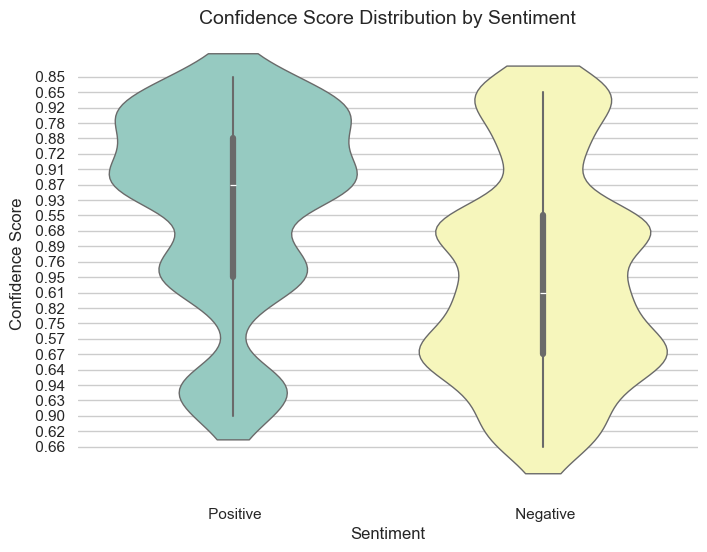

In [34]:
# 設定 Seaborn 風格
sns.set_theme(style="whitegrid")

# 設置圖形大小
plt.figure(figsize=(8, 6))

# 繪製小提琴圖
sns.violinplot(x='sentiment', y='confidence_score', data=df, bw_adjust=0.5, cut=1, linewidth=1, palette="Set3")

# 設置標題和標籤
plt.title("Confidence Score Distribution by Sentiment", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Confidence Score", fontsize=12)

# 移除不必要的邊框
sns.despine(left=True, bottom=True)

# 顯示圖表
plt.show()

5. by 'Month' and 'Sentiment'

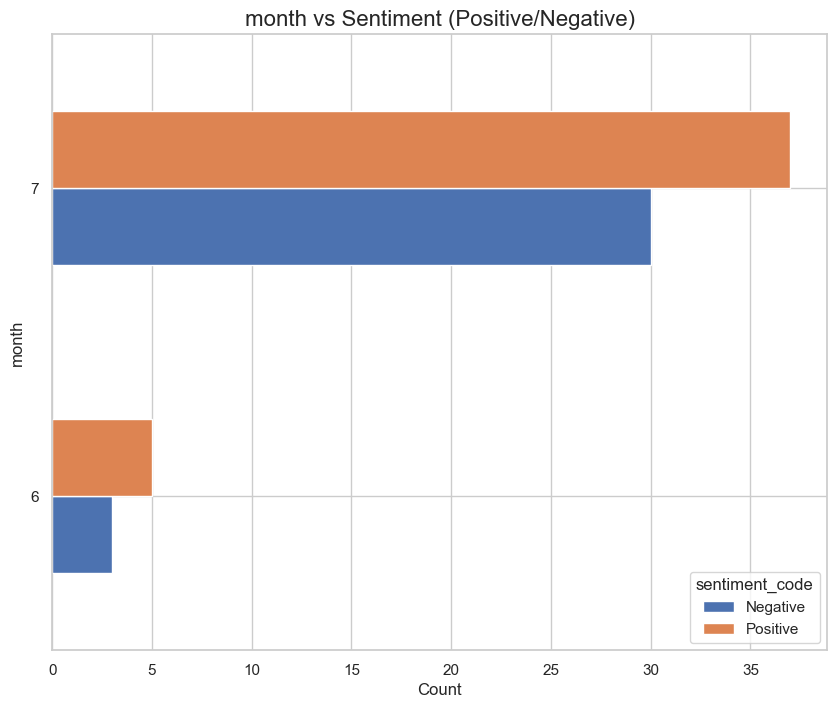

In [36]:
# 設置繪圖風格
sns.set(style="whitegrid")

# 使用 groupby 和 size 計算每個 source 中 sentiment 的分佈
source_sentiment_counts = df.groupby(['month', 'sentiment_code']).size().unstack(fill_value=0)

# 替換 sentiment_code 的 0 和 1 為 Negative 和 Positive
source_sentiment_counts.columns = source_sentiment_counts.columns.map({0: 'Negative', 1: 'Positive'})

# 繪製水平條形圖
ax = source_sentiment_counts.plot(kind='barh', stacked=False, figsize=(10, 8))

# 設置標題和標籤
ax.set_title('month vs Sentiment (Positive/Negative)', fontsize=16)
ax.set_xlabel('Count', fontsize=12)
ax.set_ylabel('month', fontsize=12)

# 顯示圖表
plt.show()

6. by 'Day' and 'Sentiment'

(array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18.]),
 [Text(0.0, 0, '0'),
  Text(2.0, 0, '2'),
  Text(4.0, 0, '4'),
  Text(6.0, 0, '6'),
  Text(8.0, 0, '8'),
  Text(10.0, 0, '10'),
  Text(12.0, 0, '12'),
  Text(14.0, 0, '14'),
  Text(16.0, 0, '16'),
  Text(18.0, 0, '18')])

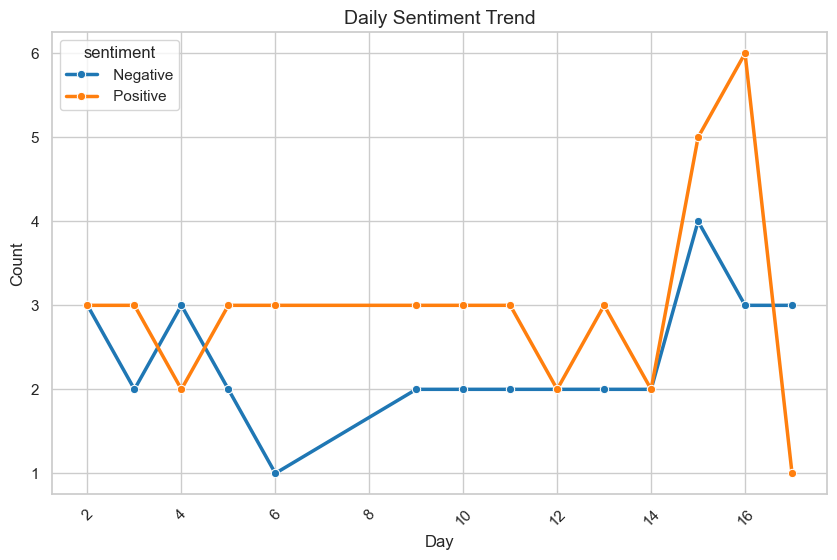

In [38]:
# 計算每日的 sentiment 數量
sentiment_counts = df.groupby(['day', 'sentiment']).size().reset_index(name='count')

# 繪製 Lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(data=sentiment_counts, x="day", y="count", hue="sentiment", marker="o", linewidth=2.5, palette="tab10")

# 設置標題與標籤
plt.title("Daily Sentiment Trend", fontsize=14)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Count", fontsize=12)

# 旋轉 X 軸標籤，使其更易讀
plt.xticks(rotation=45)

7. by 'hour' and 'Sentiment'

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75 entries, 0 to 74
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   text                              75 non-null     object        
 1   sentiment                         75 non-null     object        
 2   source                            75 non-null     object        
 3   date/time                         75 non-null     datetime64[ns]
 4   user_id                           75 non-null     object        
 5   location                          75 non-null     object        
 6   confidence_score                  75 non-null     object        
 7   month                             75 non-null     int32         
 8   day                               75 non-null     int32         
 9   hour                              75 non-null     int32         
 10  Total Words                       75 non-null     int64  

(array([ 6.,  8., 10., 12., 14., 16., 18., 20., 22.]),
 [Text(6.0, 0, '6'),
  Text(8.0, 0, '8'),
  Text(10.0, 0, '10'),
  Text(12.0, 0, '12'),
  Text(14.0, 0, '14'),
  Text(16.0, 0, '16'),
  Text(18.0, 0, '18'),
  Text(20.0, 0, '20'),
  Text(22.0, 0, '22')])

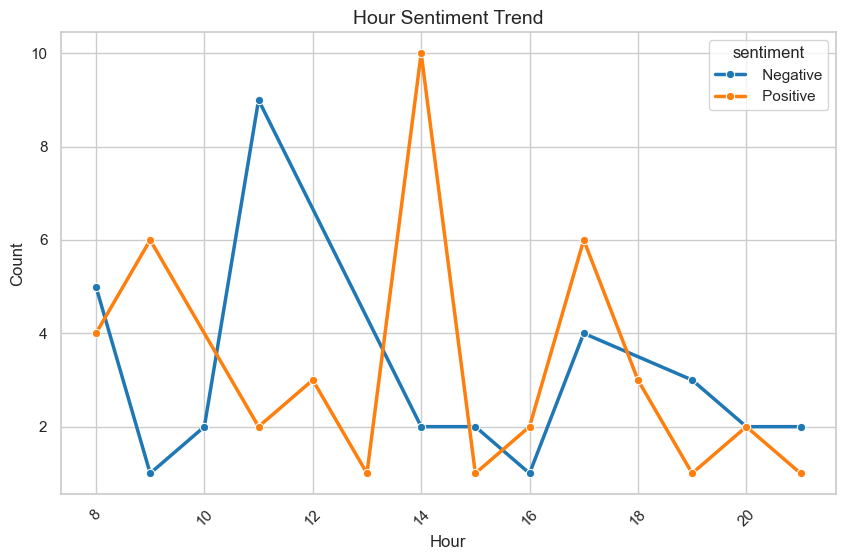

In [78]:
# 計算每小時的 sentiment 數量
sentiment_counts = df.groupby(['hour', 'sentiment']).size().reset_index(name='count')

# 繪製 Lineplot
plt.figure(figsize=(10, 6))
sns.lineplot(data=sentiment_counts, x="hour", y="count", hue="sentiment", marker="o", linewidth=2.5, palette="tab10")

# 設置標題與標籤
plt.title("Hour Sentiment Trend", fontsize=14)
plt.xlabel("Hour", fontsize=12)
plt.ylabel("Count", fontsize=12)

# 旋轉 X 軸標籤，使其更易讀
plt.xticks(rotation=45)

8. by 'Total Words' and 'Sentiment'

In [80]:
df.head()

,text,sentiment,source,date/time,user_id,location,confidence_score,month,day,hour,Total Words,Total Chars,Total Words After Transformation,sentiment_code
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,6,15,9,4,22,1.386294,1
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,6,15,11,4,27,1.386294,0
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,6,15,14,4,24,1.386294,1
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,6,15,17,7,50,1.945910,0
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,6,16,8,8,36,2.079442,1


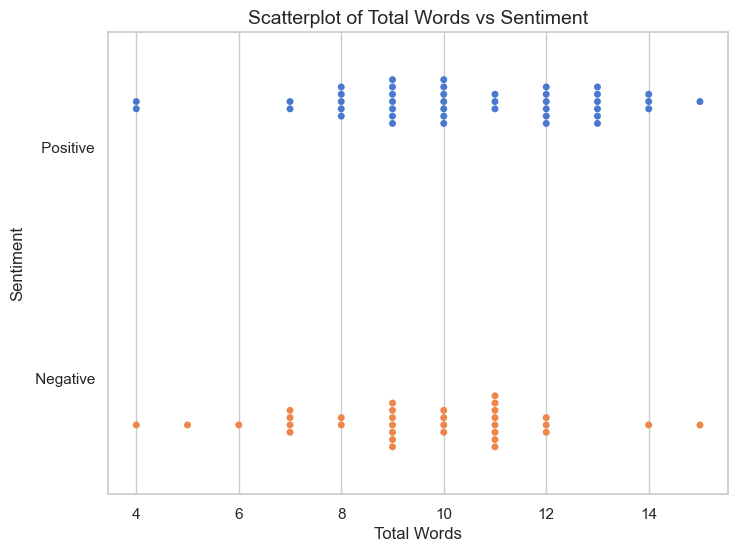

In [82]:
# 設定 Seaborn 風格
sns.set_theme(style="whitegrid", palette="muted")

# 繪製 Swarmplot（防止數據點重疊）
plt.figure(figsize=(8, 6))
ax = sns.swarmplot(data=df, x="Total Words", y="sentiment", hue="sentiment", dodge=True)

# 設置標題與標籤
ax.set_title("Scatterplot of Total Words vs Sentiment", fontsize=14)
ax.set_xlabel("Total Words", fontsize=12)
ax.set_ylabel("Sentiment", fontsize=12)

# 顯示圖表
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_4124\2321093059.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sentiment", y="Total Words", data=df, palette=["#FF9999", "#66B3FF"])


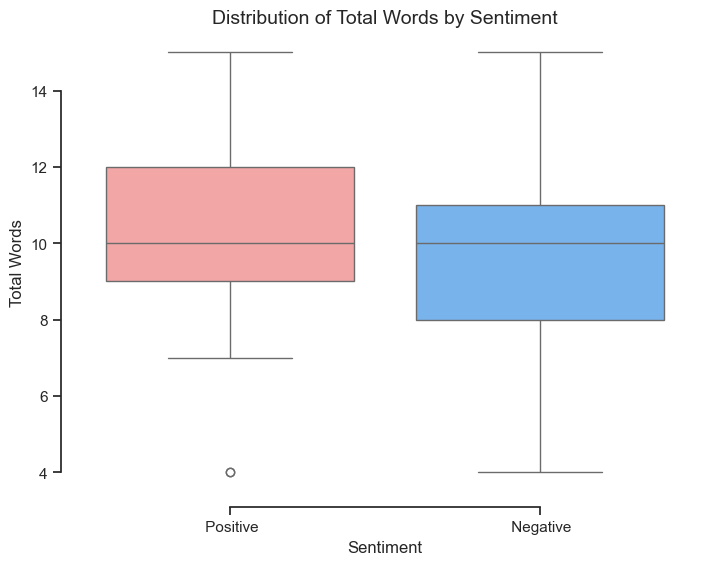

In [88]:
#Grouped boxplots
# 設定 Seaborn 風格
sns.set_theme(style="ticks", palette="pastel")

# 設置圖形大小
plt.figure(figsize=(8, 6))

# 繪製 Grouped Boxplot
sns.boxplot(x="sentiment", y="Total Words", data=df, palette=["#FF9999", "#66B3FF"])

# 優化圖表
sns.despine(offset=10, trim=True)

# 設置標題與標籤
plt.title("Distribution of Total Words by Sentiment", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Total Words", fontsize=12)

# 顯示圖表
plt.show()

9. by 'Total Chars' and 'Sentiment'

C:\Users\User\AppData\Local\Temp\ipykernel_4124\3097660740.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="sentiment", y="Total Chars", data=df, palette=["#FF9999", "#66B3FF"])


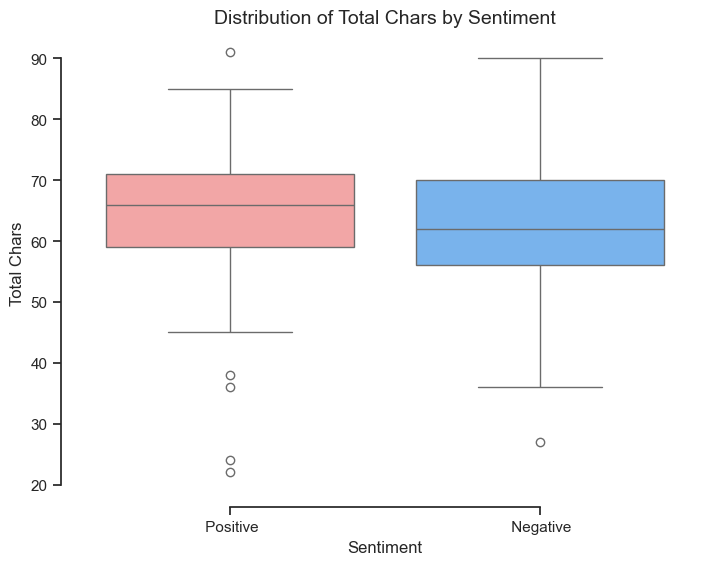

In [90]:
#Grouped boxplots
# 設定 Seaborn 風格
sns.set_theme(style="ticks", palette="pastel")

# 設置圖形大小
plt.figure(figsize=(8, 6))

# 繪製 Grouped Boxplot
sns.boxplot(x="sentiment", y="Total Chars", data=df, palette=["#FF9999", "#66B3FF"])

# 優化圖表
sns.despine(offset=10, trim=True)

# 設置標題與標籤
plt.title("Distribution of Total Chars by Sentiment", fontsize=14)
plt.xlabel("Sentiment", fontsize=12)
plt.ylabel("Total Chars", fontsize=12)

# 顯示圖表
plt.show()

10. Wordcloud by Sentiment = Negative

In [92]:
df.head()

,text,sentiment,source,date/time,user_id,location,confidence_score,month,day,hour,Total Words,Total Chars,Total Words After Transformation,sentiment_code
0,"""I love this product!""",Positive,Twitter,2023-06-15 09:23:14,@user123,New York,0.85,6,15,9,4,22,1.386294,1
1,"""The service was terrible.""",Negative,Yelp Reviews,2023-06-15 11:45:32,user456,Los Angeles,0.65,6,15,11,4,27,1.386294,0
2,"""This movie is amazing!""",Positive,IMDb,2023-06-15 14:10:22,moviefan789,London,0.92,6,15,14,4,24,1.386294,1
3,"""I'm so disappointed with their customer suppo...",Negative,Online Forum,2023-06-15 17:35:11,forumuser1,Toronto,0.78,6,15,17,7,50,1.945910,0
4,"""Just had the best meal of my life!""",Positive,TripAdvisor,2023-06-16 08:50:59,foodie22,Paris,0.88,6,16,8,8,36,2.079442,1


In [110]:
!pip install wordcloud
import wordcloud
print("WordCloud 模組已成功載入！")

WordCloud 模組已成功載入！


In [113]:
# 檢查 sentiment 欄位的唯一值
print(df['sentiment'].unique()) 

[' Positive' ' Negative']


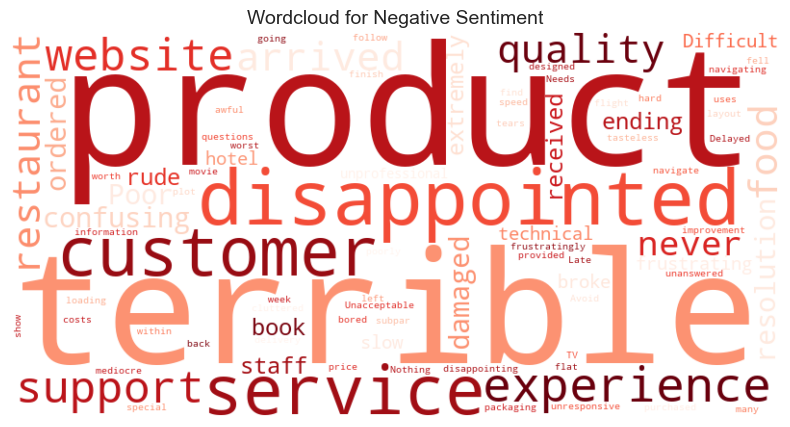

In [115]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# 篩選 sentiment = Negative 的文本
negative_text = " ".join(df[df['sentiment'] == ' Negative']['text'])

# 產生文字雲
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negative_text)

# 繪製圖表
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 移除軸線
plt.title("Wordcloud for Negative Sentiment", fontsize=14)
plt.show()

11. Wordcloud by Sentiment = Positive

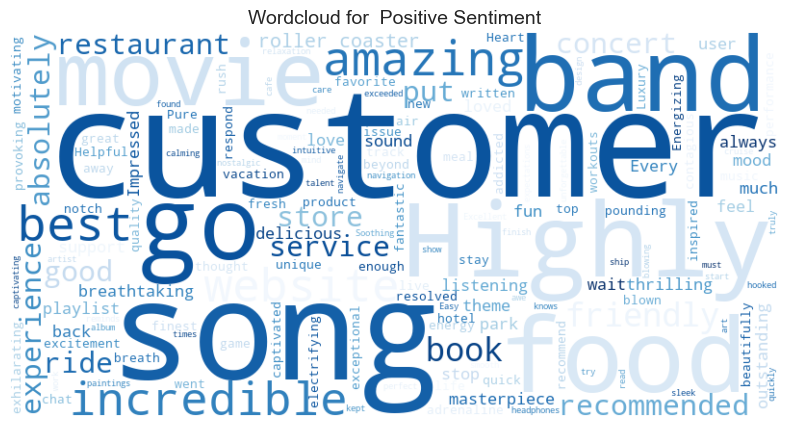

In [117]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt
# 篩選 sentiment = Negative 的文本
negative_text = " ".join(df[df['sentiment'] == ' Positive']['text'])

# 產生文字雲
wordcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(negative_text)

# 繪製圖表
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")  # 移除軸線
plt.title("Wordcloud for  Positive Sentiment", fontsize=14)
plt.show()

12. by Top 25 Negative Words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


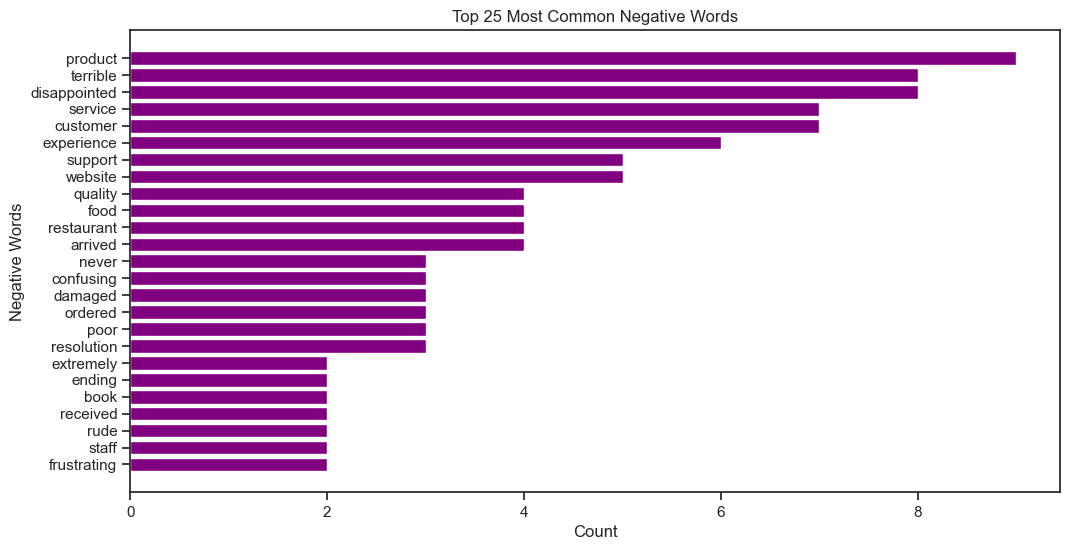

In [177]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
import re

# 確保你已下載 nltk 的 stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 將 'im' 加入到停用詞中，因為測試時發現這個無意義的詞混入其中
stop_words.add('im')

# 篩選 Negative Sentiment 的文本
negative_texts = df[df['sentiment'].str.lower() == ' negative']['text'].dropna().astype(str)

# 轉換成單一大文本
all_negative_text = " ".join(negative_texts)

# 清理文本：移除標點符號、數字，並轉為小寫
all_negative_text = re.sub(r"[^a-zA-Z\s]", "", all_negative_text).lower()

# 分詞（Tokenization）
words = all_negative_text.split()

# 過濾掉停用詞
filtered_words = [word for word in words if word not in stop_words]

# 計算詞頻
word_counts = Counter(filtered_words)

# 取得最常見的 25 個詞
top_negative_words = word_counts.most_common(25)

# 轉為 DataFrame 以便視覺化
top_words_df = pd.DataFrame(top_negative_words, columns=['Word', 'Count'])

# 繪製條形圖
plt.figure(figsize=(12, 6))
plt.barh(top_words_df['Word'], top_words_df['Count'], color='purple')
plt.xlabel("Count")
plt.ylabel("Negative Words")
plt.title("Top 25 Most Common Negative Words")
plt.gca().invert_yaxis()  # 讓最高頻的詞彙排在上方
plt.show()

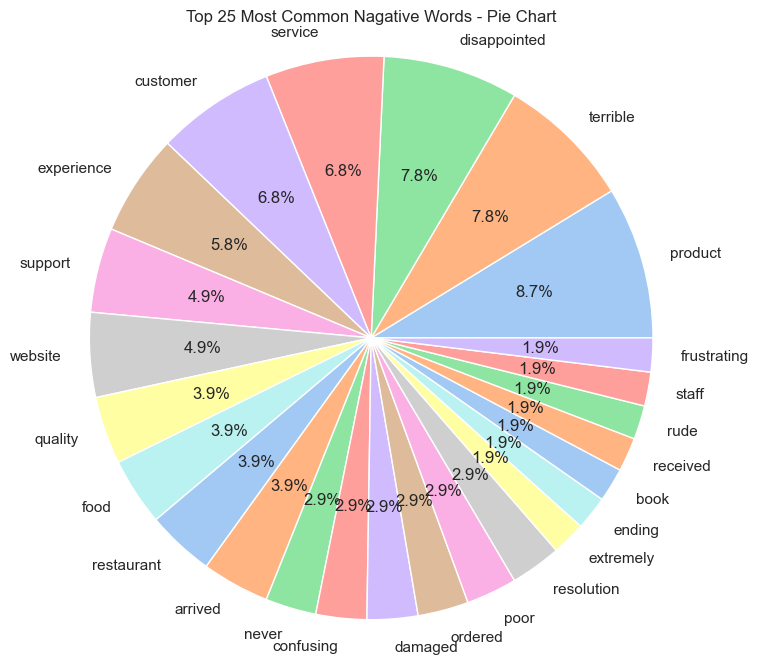

In [179]:
# 繪製圓餅圖
plt.figure(figsize=(8, 8))
plt.pie(top_words_df['Count'], labels=top_words_df['Word'], autopct='%1.1f%%')
plt.title("Top 25 Most Common Nagative Words - Pie Chart")
plt.axis("equal")  # 讓圓餅圖看起來像圓形
plt.show()

13. by Top 25 Positive Words

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


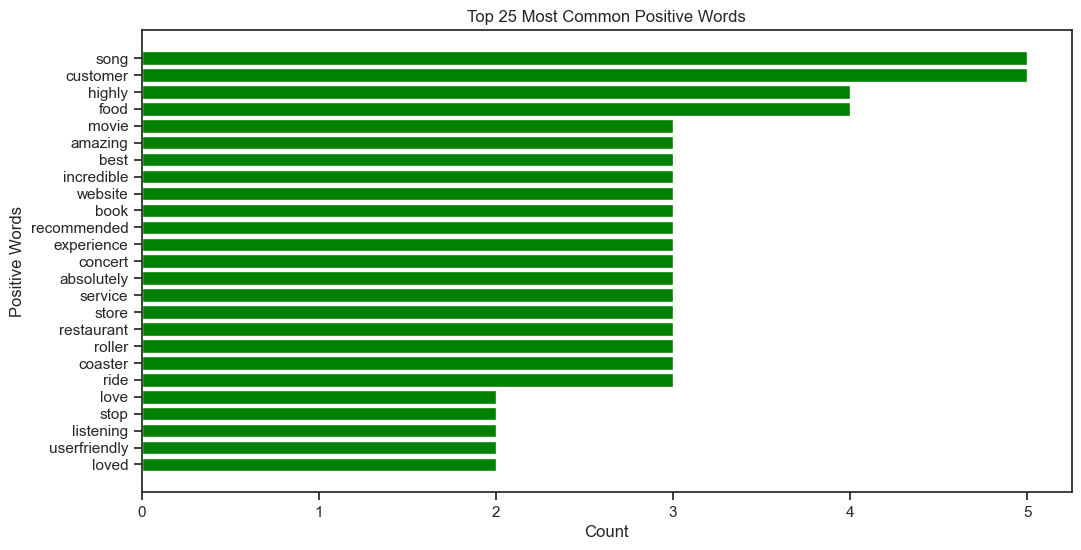

In [182]:
# 確保你已下載 nltk 的 stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# 將 'im' 加入到停用詞中，因為測試時發現這個無意義的詞混入其中
stop_words.add('im')
stop_words.add('cant')
# 篩選 Positive Sentiment 的文本
positive_texts = df[df['sentiment'].str.lower() == ' positive']['text'].dropna().astype(str)

# 轉換成單一大文本
all_positive_text = " ".join(positive_texts)

# 清理文本：移除標點符號、數字，並轉為小寫
all_positive_text = re.sub(r"[^a-zA-Z\s]", "", all_positive_text).lower()

# 分詞（Tokenization）
words = all_positive_text.split()

# 過濾掉停用詞
filtered_words = [word for word in words if word not in stop_words]

# 計算詞頻
word_counts = Counter(filtered_words)

# 取得最常見的 25 個詞
top_positive_words = word_counts.most_common(25)

# 轉為 DataFrame 以便視覺化
top_words_df = pd.DataFrame(top_positive_words, columns=['Word', 'Count'])

# 繪製條形圖
plt.figure(figsize=(12, 6))
plt.barh(top_words_df['Word'], top_words_df['Count'], color='green')
plt.xlabel("Count")
plt.ylabel("Positive Words")
plt.title("Top 25 Most Common Positive Words")
plt.gca().invert_yaxis()  # 讓最高頻的詞彙排在上方
plt.show()


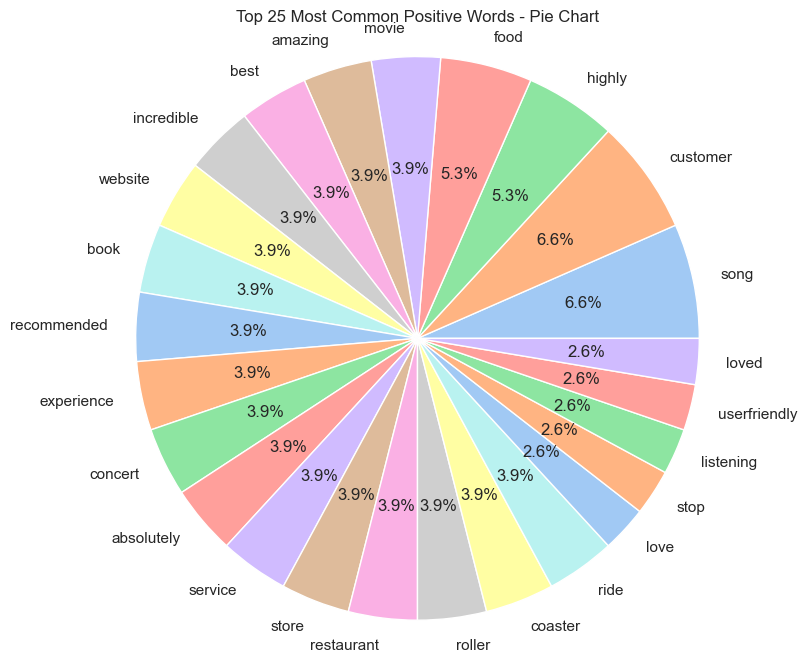

In [184]:
# 繪製圓餅圖
plt.figure(figsize=(8, 8))
plt.pie(top_words_df['Count'], labels=top_words_df['Word'], autopct='%1.1f%%')
plt.title("Top 25 Most Common Positive Words - Pie Chart")
plt.axis("equal")  # 讓圓餅圖看起來像圓形
plt.show()